# Cross-region generalization check -- Shangri-La (Yunnan) & Horqin Sandy Land (Liaoning)

The original paper (John & Zhang, 2022) tested cross-region transferability by applying its
Amazon-trained model directly to Atlantic Forest imagery (and vice versa) with **no retraining**.
We can't do the exact analogue (our Amazon replication is 3-band RGB, our Harbin data is 4-band
RGB+NIR -- a channel mismatch), so instead this notebook applies the already-trained **Harbin
filtered model** directly to two genuinely new Chinese regions it has never seen, with no
retraining and no ground truth -- a visual plausibility check only, same spirit as the T52TDT
unlabeled-scene check.

- **Shangri-La (Zhongdian), Yunnan** -- MGRS tile T47RNL. High-altitude alpine/subalpine
  coniferous forest, a real cross-biome domain shift from Heilongjiang's boreal-temperate forest.
- **Horqin Sandy Land / Zhanggutai, Liaoning** -- MGRS tile T51TVH. A Three-North Shelterbelt
  afforestation site, same broad climate zone as the training data but historically low-forest --
  tests whether the model recognizes young/planted forest.

Both sites' imagery was downloaded (`download-crossregion-sentinel2-data.py`), preprocessed
(`preprocess-haerbing-sentinel2-data.py`), and packaged (`package-crossregion-scene.py`) into
`CrossRegion_scene.tar` -- upload that tar to your Drive `COMP0173/` folder before running this.

In [1]:
# Colab setup: mount Drive, clone the repo, extract the cross-region scene
# tar, and locate the trained Harbin filtered model (copied to Drive at
# the end of code_phase2_harbin_filtered.ipynb).
import os
import shutil

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

MODEL_FILENAME = "unet-attention-4d-harbin-filtered.hdf5"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_DIR = "/content/COMP0173_poster_pre"
    if not os.path.exists(REPO_DIR):
        !git clone -q https://github.com/jy-gfm/COMP0173_poster_pre.git {REPO_DIR}
    os.chdir(REPO_DIR)

    DRIVE_DIR = "/content/drive/MyDrive/COMP0173/"

    SCENE_DIR = "/content/CrossRegion_scene"
    if not os.path.exists(SCENE_DIR):
        !tar -xf {DRIVE_DIR}CrossRegion_scene.tar -C /content 2>&1 | grep -v "Ignoring unknown extended header keyword" || true

    MODEL_PATH = f"/content/{MODEL_FILENAME}"
    if not os.path.exists(MODEL_PATH):
        shutil.copy(f"{DRIVE_DIR}{MODEL_FILENAME}", MODEL_PATH)
else:
    SCENE_DIR = "./CrossRegion_scene"
    MODEL_PATH = MODEL_FILENAME

print("SCENE_DIR:", SCENE_DIR)
print("MODEL_PATH:", MODEL_PATH)

Mounted at /content/drive
SCENE_DIR: /content/CrossRegion_scene
MODEL_PATH: /content/unet-attention-4d-harbin-filtered.hdf5


In [2]:
# If keras raises an error about adam_v2 or a similar legacy-API mismatch,
# restart the runtime after this cell (Runtime > Restart session) before
# proceeding -- same fix needed throughout this project's other notebooks.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tf_keras as keras

model = keras.models.load_model(MODEL_PATH, compile=False)
print("Loaded:", MODEL_PATH)

Loaded: /content/unet-attention-4d-harbin-filtered.hdf5


In [3]:
import glob
import numpy as np
import matplotlib.pyplot as plt

def stretch_for_display(rgb, low_pct=2, high_pct=98, gamma=0.6):
    # Raw Sentinel-2 reflectance is typically 0.03-0.15 for land surfaces --
    # displaying it on a raw 0-1 scale looks almost black. This is a
    # display-only fix (percentile contrast stretch + gamma brightening);
    # it does not touch the actual numeric data fed to the model.
    stretched = np.zeros_like(rgb)
    for c in range(rgb.shape[-1]):
        band = rgb[:, :, c]
        lo, hi = np.percentile(band, [low_pct, high_pct])
        stretched[:, :, c] = np.clip((band - lo) / max(hi - lo, 1e-6), 0, 1)
    return np.clip(stretched, 0, 1) ** gamma

REGION_LABELS = {
    "T47RNL": "Shangri-La (Yunnan)",
    "T51TVH": "Horqin Sandy Land (Liaoning)",
}

for tile in ["T47RNL", "T51TVH"]:
    n = len(glob.glob(f"{SCENE_DIR}/{tile}/*_image.npy"))
    print(f"{tile} ({REGION_LABELS[tile]}): {n} tiles available")

T47RNL (Shangri-La (Yunnan)): 12 tiles available
T51TVH (Horqin Sandy Land (Liaoning)): 12 tiles available


## Visual check -- no ground truth, no retraining

This is purely a plausibility check: does the model produce a sane-looking forest/non-forest
mask on terrain it has never been trained or evaluated on? NDVI is shown for visual reference
only -- it is **not** a label here, since these tiles were never run through the ground-truth
generation pipeline (same convention as the T52TDT unlabeled-scene check).

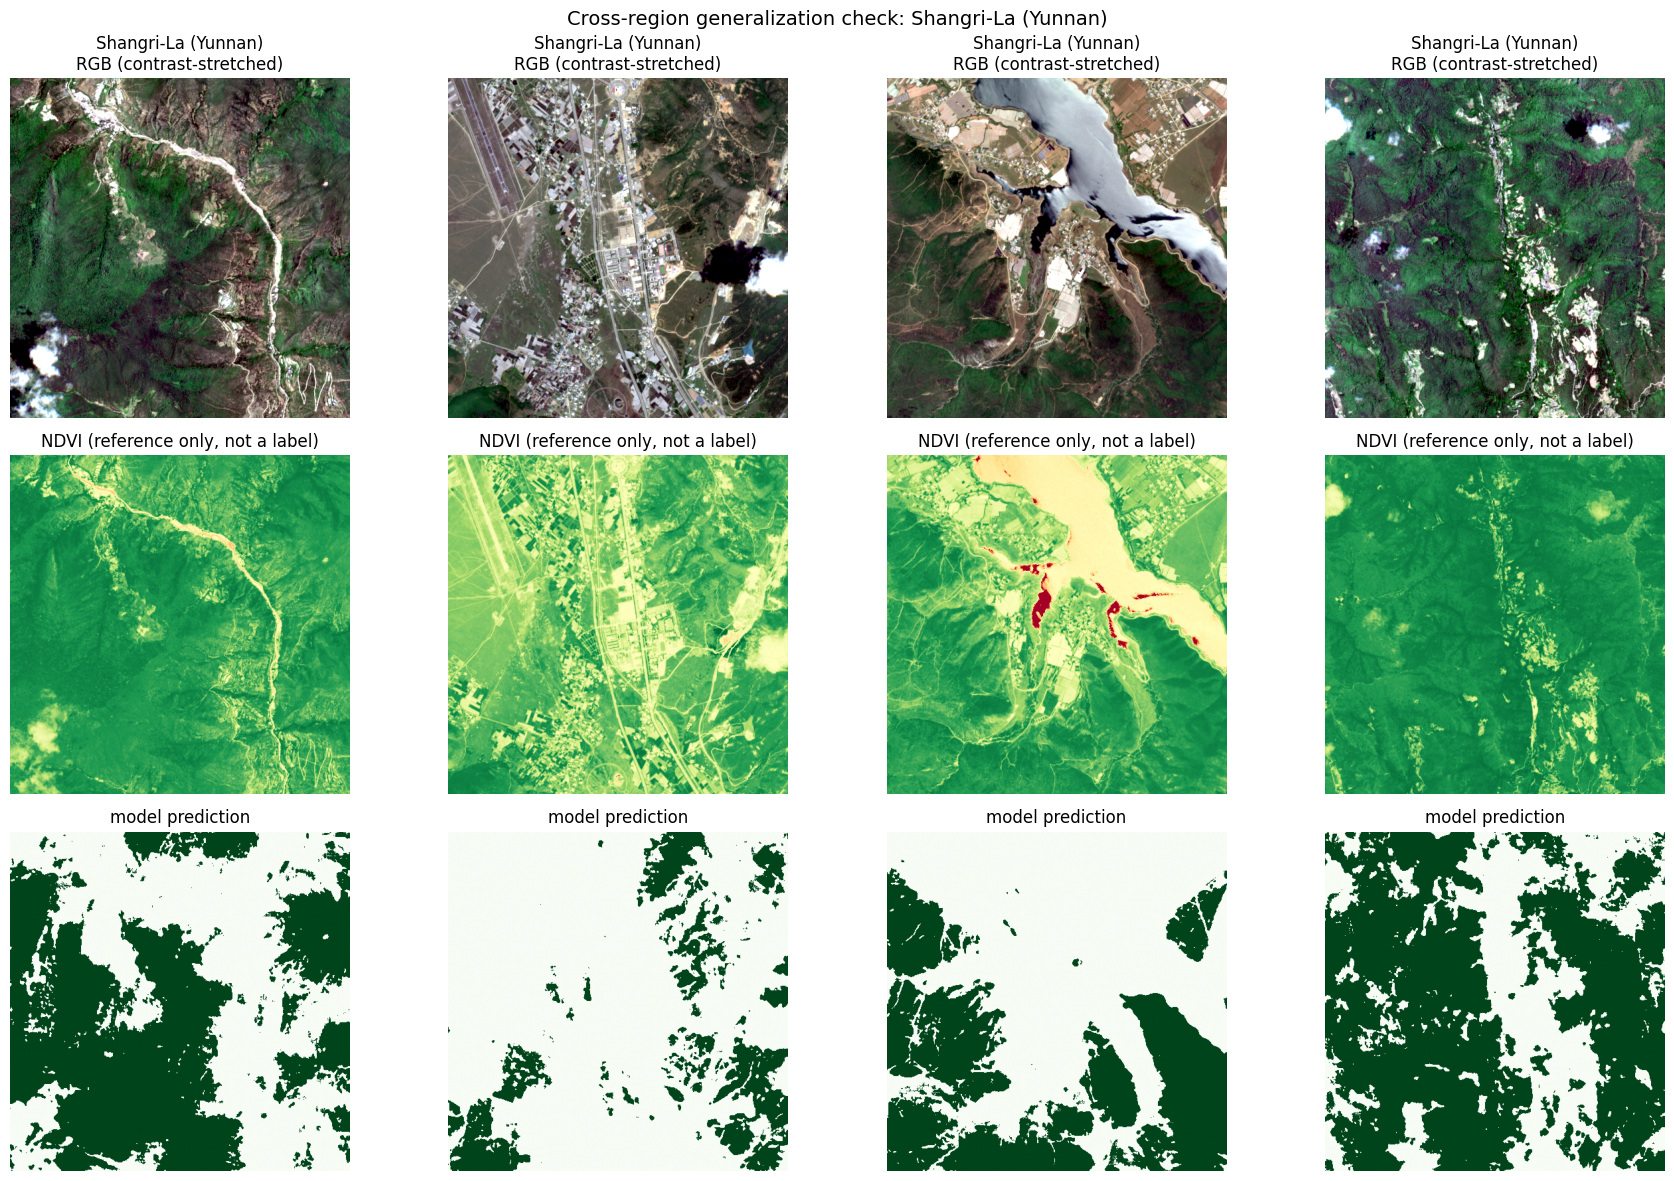

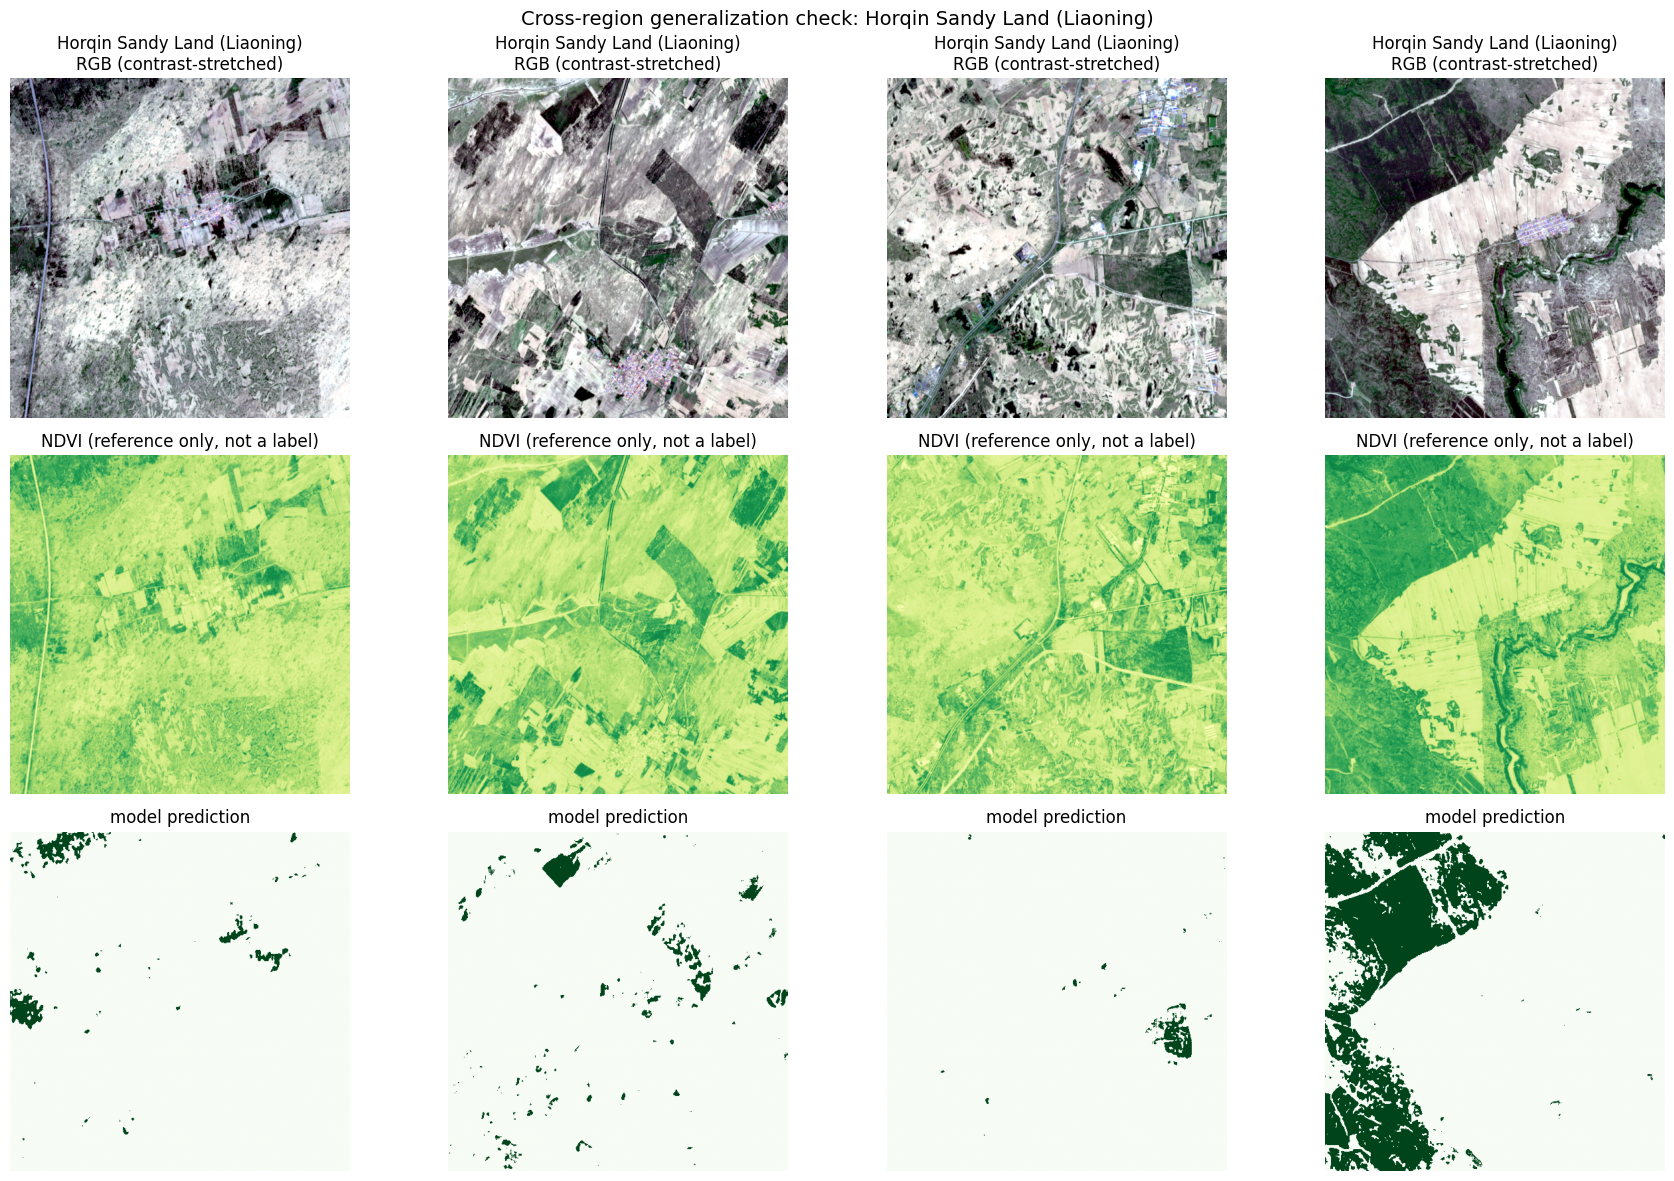

In [4]:
for tile, label in REGION_LABELS.items():
    image_paths = sorted(glob.glob(f"{SCENE_DIR}/{tile}/*_image.npy"))[:4]
    fig, axes = plt.subplots(3, len(image_paths), figsize=(4.5 * len(image_paths), 12))
    for col, img_path in enumerate(image_paths):
        img = np.load(img_path).reshape(1, 512, 512, 4)
        ndvi = np.load(img_path.replace("_image.npy", "_ndvi.npy"))
        pred = np.round(model.predict(img, verbose=0))[0, :, :, 0]

        axes[0, col].imshow(stretch_for_display(img[0][:, :, :3]))
        axes[0, col].set_title(f"{label}\nRGB (contrast-stretched)")
        axes[0, col].axis("off")

        axes[1, col].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
        axes[1, col].set_title("NDVI (reference only, not a label)")
        axes[1, col].axis("off")

        axes[2, col].imshow(pred, cmap="Greens", vmin=0, vmax=1)
        axes[2, col].set_title("model prediction")
        axes[2, col].axis("off")
    plt.suptitle(f"Cross-region generalization check: {label}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"/content/crossregion_{tile}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Write-up prompt for the poster

After running the cell above, look at both figures and write 2-3 sentences per region on:
- Does the predicted mask look spatially plausible (e.g. following visible forest/non-forest
  boundaries), or does it look like noise / a trivial all-one-class output?
- For Horqin specifically: does the model pick out the darker planted-forest patches against
  the sandy background, or does it miss them / over-predict forest everywhere?
- For Shangri-La: does elevation/terrain shading confuse the model (e.g. dark shadowed slopes
  predicted as forest when they aren't, or vice versa)?

This is Discussion-panel material -- an honest description of what generalizes and what doesn't
is worth more here than a simple pass/fail verdict.